## Credit Card Fraud Detection Using Machine Learning and Deep Learning

## Install Libraries

In [ ]:
!pip install --upgrade scikit-learn imbalanced-learn

In [ ]:
!pip install pandas numpy matplotlib seaborn scikit-learn imbalanced-learn tensorflow

### Import Libraries

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.metrics import precision_score, recall_score, f1_score, roc_auc_score
from sklearn.metrics import roc_curve

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from imblearn.over_sampling import SMOTE

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout


# Load Dataset

In [4]:
df = pd.read_csv("creditcard.csv")

print(df.head())

   Time        V1        V2        V3        V4        V5        V6        V7  \
0   0.0 -1.359807 -0.072781  2.536347  1.378155 -0.338321  0.462388  0.239599   
1   0.0  1.191857  0.266151  0.166480  0.448154  0.060018 -0.082361 -0.078803   
2   1.0 -1.358354 -1.340163  1.773209  0.379780 -0.503198  1.800499  0.791461   
3   1.0 -0.966272 -0.185226  1.792993 -0.863291 -0.010309  1.247203  0.237609   
4   2.0 -1.158233  0.877737  1.548718  0.403034 -0.407193  0.095921  0.592941   

         V8        V9  ...       V21       V22       V23       V24       V25  \
0  0.098698  0.363787  ... -0.018307  0.277838 -0.110474  0.066928  0.128539   
1  0.085102 -0.255425  ... -0.225775 -0.638672  0.101288 -0.339846  0.167170   
2  0.247676 -1.514654  ...  0.247998  0.771679  0.909412 -0.689281 -0.327642   
3  0.377436 -1.387024  ... -0.108300  0.005274 -0.190321 -1.175575  0.647376   
4 -0.270533  0.817739  ... -0.009431  0.798278 -0.137458  0.141267 -0.206010   

        V26       V27       V28 

In [5]:
# Shape

print(df.shape)

(284807, 31)


In [6]:
#INFO

print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 284807 entries, 0 to 284806
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    284807 non-null  float64
 1   V1      284807 non-null  float64
 2   V2      284807 non-null  float64
 3   V3      284807 non-null  float64
 4   V4      284807 non-null  float64
 5   V5      284807 non-null  float64
 6   V6      284807 non-null  float64
 7   V7      284807 non-null  float64
 8   V8      284807 non-null  float64
 9   V9      284807 non-null  float64
 10  V10     284807 non-null  float64
 11  V11     284807 non-null  float64
 12  V12     284807 non-null  float64
 13  V13     284807 non-null  float64
 14  V14     284807 non-null  float64
 15  V15     284807 non-null  float64
 16  V16     284807 non-null  float64
 17  V17     284807 non-null  float64
 18  V18     284807 non-null  float64
 19  V19     284807 non-null  float64
 20  V20     284807 non-null  float64
 21  V21     28

In [7]:
print(df["Class"].value_counts())

Class
0    284315
1       492
Name: count, dtype: int64


#### Checking Missing Values

In [8]:
print(df.isnull().sum())

Time      0
V1        0
V2        0
V3        0
V4        0
V5        0
V6        0
V7        0
V8        0
V9        0
V10       0
V11       0
V12       0
V13       0
V14       0
V15       0
V16       0
V17       0
V18       0
V19       0
V20       0
V21       0
V22       0
V23       0
V24       0
V25       0
V26       0
V27       0
V28       0
Amount    0
Class     0
dtype: int64


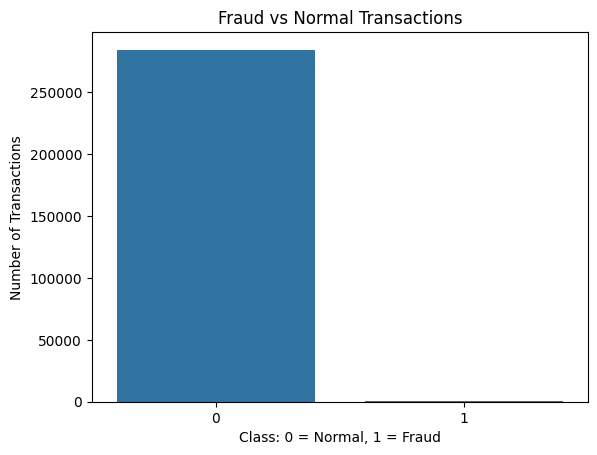

In [9]:
#  Visualization - Fraud vs Normal Transactions

sns.countplot(x="Class", data=df)
plt.title("Fraud vs Normal Transactions")
plt.xlabel("Class: 0 = Normal, 1 = Fraud")
plt.ylabel("Number of Transactions")
plt.show()

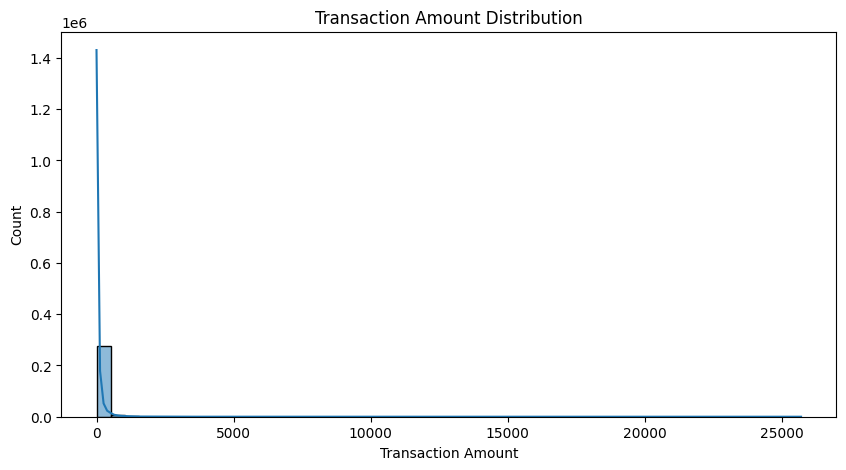

In [10]:
# Visualization - Transaction Amount Distribution

plt.figure(figsize=(10, 5))
sns.histplot(df["Amount"], bins=50, kde=True)
plt.title("Transaction Amount Distribution")
plt.xlabel("Transaction Amount")
plt.ylabel("Count")
plt.show()

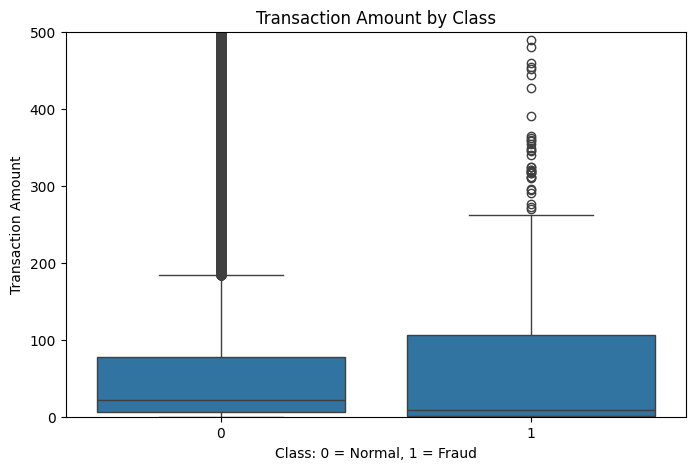

In [11]:
# Visualization - Transaction Amount by Class

plt.figure(figsize=(8, 5))
sns.boxplot(x="Class", y="Amount", data=df)
plt.title("Transaction Amount by Class")
plt.xlabel("Class: 0 = Normal, 1 = Fraud")
plt.ylabel("Transaction Amount")
plt.ylim(0, 500)
plt.show()

In [12]:
# Split Features and Target

X = df.drop("Class", axis=1)
y = df["Class"]


In [13]:
# Train-Test Split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [14]:
# Scale Time and Amount

scaler = StandardScaler()

X_train = X_train.copy()
X_test = X_test.copy()

X_train[["Time", "Amount"]] = scaler.fit_transform(X_train[["Time", "Amount"]])
X_test[["Time", "Amount"]] = scaler.transform(X_test[["Time", "Amount"]])


In [15]:
# Handle Imbalanced Data Using SMOTE

smote = SMOTE(random_state=42)

X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)

print(y_train_smote.value_counts())


Class
0    227451
1    227451
Name: count, dtype: int64


In [16]:
# Train Logistic Regression

lr = LogisticRegression(max_iter=1000)
lr.fit(X_train_smote, y_train_smote)

lr_pred = lr.predict(X_test)
lr_prob = lr.predict_proba(X_test)[:, 1]

print(classification_report(y_test, lr_pred))


              precision    recall  f1-score   support

           0       1.00      0.97      0.99     56864
           1       0.06      0.92      0.11        98

    accuracy                           0.97     56962
   macro avg       0.53      0.95      0.55     56962
weighted avg       1.00      0.97      0.99     56962



In [17]:
# Train Random Forest

rf = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)

rf.fit(X_train_smote, y_train_smote)

rf_pred = rf.predict(X_test)
rf_prob = rf.predict_proba(X_test)[:, 1]

print(classification_report(y_test, rf_pred))


              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56864
           1       0.85      0.84      0.84        98

    accuracy                           1.00     56962
   macro avg       0.92      0.92      0.92     56962
weighted avg       1.00      1.00      1.00     56962



In [18]:
# Train Deep Learning Model

dl_model = Sequential([
    Dense(64, activation="relu", input_shape=(X_train_smote.shape[1],)),
    Dropout(0.3),
    Dense(32, activation="relu"),
    Dropout(0.2),
    Dense(1, activation="sigmoid")
])

dl_model.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

history = dl_model.fit(
    X_train_smote,
    y_train_smote,
    epochs=10,
    batch_size=64,
    validation_split=0.2
)


C:\Users\Vinay kumar\anac\Lib\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/10
5687/5687 ━━━━━━━━━━━━━━━━━━━━ 44s 7ms/step - accuracy: 0.9837 - loss: 0.0448 - val_accuracy: 0.9994 - val_loss: 0.0123
Epoch 2/10
5687/5687 ━━━━━━━━━━━━━━━━━━━━ 39s 7ms/step - accuracy: 0.9966 - loss: 0.0122 - val_accuracy: 0.9998 - val_loss: 0.0040
Epoch 3/10
5687/5687 ━━━━━━━━━━━━━━━━━━━━ 42s 7ms/step - accuracy: 0.9978 - loss: 0.0087 - val_accuracy: 0.9999 - val_loss: 0.0028
Epoch 4/10
5687/5687 ━━━━━━━━━━━━━━━━━━━━ 41s 7ms/step - accuracy: 0.9981 - loss: 0.0076 - val_accuracy: 0.9998 - val_loss: 0.0033
Epoch 5/10
5687/5687 ━━━━━━━━━━━━━━━━━━━━ 40s 7ms/step - accuracy: 0.9984 - loss: 0.0063 - val_accuracy: 1.0000 - val_loss: 0.0018
Epoch 6/10
5687/5687 ━━━━━━━━━━━━━━━━━━━━ 41s 7ms/step - accuracy: 0.9985 - loss: 0.0059 - val_accuracy: 1.0000 - val_loss: 0.0021
Epoch 7/10
5687/5687 ━━━━━━━━━━━━━━━━━━━━ 40s 7ms/step - accuracy: 0.9987 - loss: 0.0054 - val_accuracy: 0.9987 - val_loss: 0.0047
Epoch 8/10
5687/5687 ━━━━━━━━━━━━━━━━━━━━ 37s 6ms/step - accuracy: 0.9988 - loss: 0

In [19]:
# Evaluate Deep Learning Model

dl_prob = dl_model.predict(X_test).ravel()
dl_pred = (dl_prob > 0.5).astype(int)

print(classification_report(y_test, dl_pred))


1781/1781 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56864
           1       0.61      0.85      0.71        98

    accuracy                           1.00     56962
   macro avg       0.81      0.92      0.86     56962
weighted avg       1.00      1.00      1.00     56962



In [20]:
# Create Model Comparison Table

results = pd.DataFrame({
    "Model": ["Logistic Regression", "Random Forest", "Neural Network"],
    "Precision": [
        precision_score(y_test, lr_pred),
        precision_score(y_test, rf_pred),
        precision_score(y_test, dl_pred)
    ],
    "Recall": [
        recall_score(y_test, lr_pred),
        recall_score(y_test, rf_pred),
        recall_score(y_test, dl_pred)
    ],
    "F1-Score": [
        f1_score(y_test, lr_pred),
        f1_score(y_test, rf_pred),
        f1_score(y_test, dl_pred)
    ],
    "ROC-AUC": [
        roc_auc_score(y_test, lr_prob),
        roc_auc_score(y_test, rf_prob),
        roc_auc_score(y_test, dl_prob)
    ]
})

results.round(4)


,Model,Precision,Recall,F1-Score,ROC-AUC
0,Logistic Regression,0.0580,0.9184,0.1092,0.9699
1,Random Forest,0.8454,0.8367,0.8410,0.9731
2,Neural Network,0.6148,0.8469,0.7124,0.9784


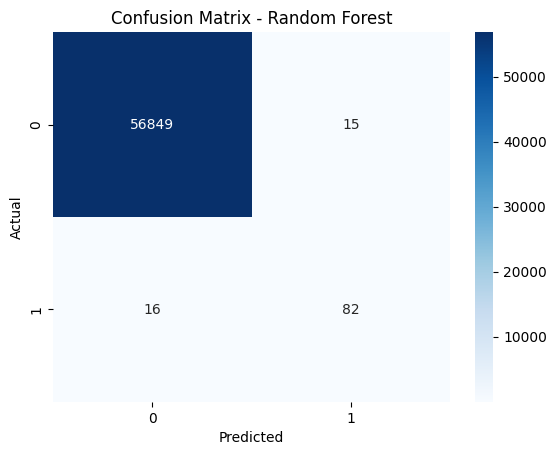

In [21]:
# Visualization - Confusion Matrix

cm = confusion_matrix(y_test, rf_pred)

sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.title("Confusion Matrix - Random Forest")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()


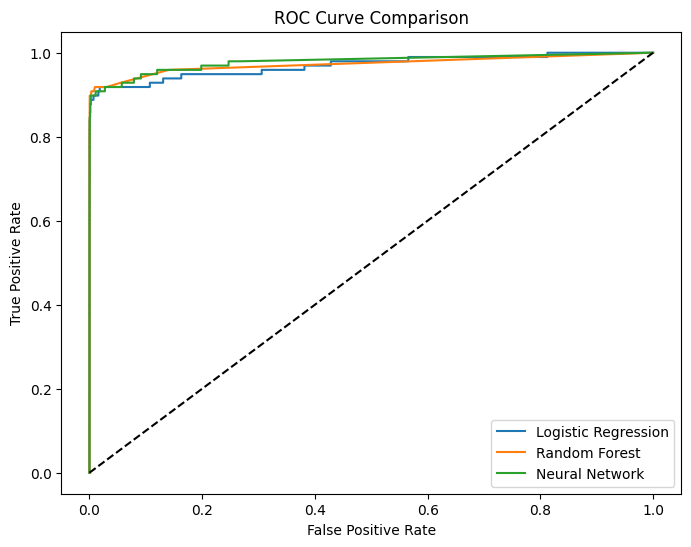

In [22]:
# Visualization - ROC Curve Comparison

lr_fpr, lr_tpr, _ = roc_curve(y_test, lr_prob)
rf_fpr, rf_tpr, _ = roc_curve(y_test, rf_prob)
dl_fpr, dl_tpr, _ = roc_curve(y_test, dl_prob)

plt.figure(figsize=(8, 6))

plt.plot(lr_fpr, lr_tpr, label="Logistic Regression")
plt.plot(rf_fpr, rf_tpr, label="Random Forest")
plt.plot(dl_fpr, dl_tpr, label="Neural Network")

plt.plot([0, 1], [0, 1], "k--")

plt.title("ROC Curve Comparison")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()
plt.show()


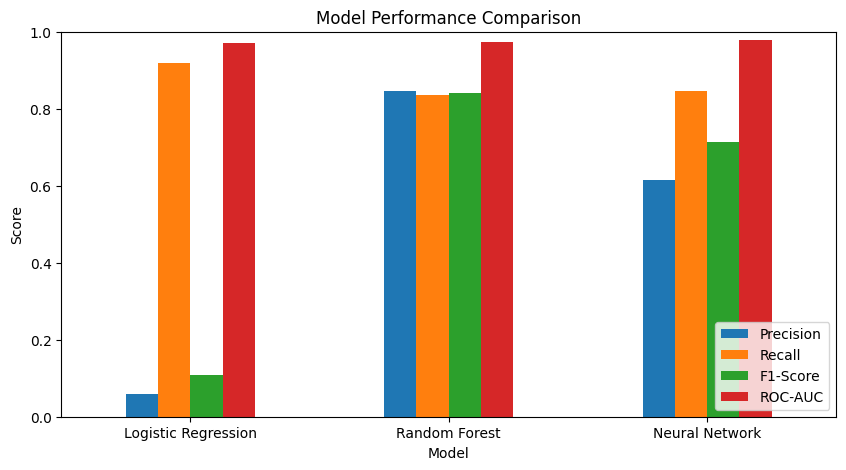

In [23]:
# Visualization - Model Performance Comparison

results.set_index("Model")[["Precision", "Recall", "F1-Score", "ROC-AUC"]].plot(
    kind="bar",
    figsize=(10, 5)
)

plt.title("Model Performance Comparison")
plt.ylabel("Score")
plt.xlabel("Model")
plt.xticks(rotation=0)
plt.ylim(0, 1)
plt.legend(loc="lower right")
plt.show()


In [24]:
joblib.dump(rf, "fraud_detection_model.pkl")
joblib.dump(scaler, "scaler.pkl")


['scaler.pkl']

# Conclusion:

This project developed a Credit Card Fraud Detection system using Machine Learning and Deep Learning. The dataset was highly imbalanced, so SMOTE was used to balance the training data. Logistic Regression, Random Forest, and Neural Network models were trained and compared using Precision, Recall, F1-Score, and ROC-AUC.

For fraud detection, Recall and F1-Score are more important than accuracy because missing fraudulent transactions can cause financial loss. Based on the model comparison, the best-performing model can be used to identify suspicious transactions.
